# 6. Write a program to perform following operations for sharpening an image:
    a. Take an image (attached)
    b. Apply Laplacian filter
    c. Obtain sharpen image by adding ‘a’ and ‘b’



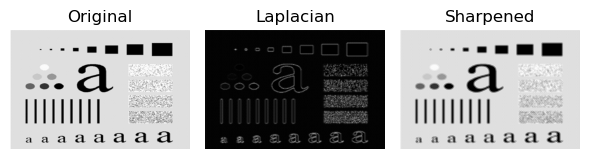

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read image at {path}")
    return img

# def laplacian_sharpening(image):
#     lap = cv2.Laplacian(image, cv2.CV_64F, ksize=3)
#     lap = np.clip(lap, -255, 255) 
#     lap_abs = cv2.convertScaleAbs(lap)  

#     sharpened = cv2.add(image, lap_abs)
#     sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

#     return lap_abs, sharpened

def convolve(image, kernel):
    kH, kW = kernel.shape
    pad_y, pad_x = kH // 2, kW // 2
    padded_img = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+kH, j:j+kW]
            output[i, j] = np.sum(region * kernel)

    return output

def laplacian_sharpening(image):
    lap_kernel = np.array([[0,  1,  0],
                           [1, -4,  1],
                           [0,  1,  0]], dtype=np.float32)

    lap = convolve(image, lap_kernel)

    lap_abs = np.abs(lap)  
    lap_abs = np.clip(lap_abs, 0, 255).astype(np.uint8)

    sharpened = np.add(image.astype(np.int16), lap.astype(np.int16))
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return lap_abs, sharpened

def plot_results(original, laplacian, sharpened):
    plt.figure(figsize=(6, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(laplacian, cmap='gray')
    plt.title("Laplacian")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig("outimg_problem6.png")
    plt.show()

def main():
    img_path = "../test_imgs/test_img.png"
    img = read_image(img_path)

    laplacian, sharpened = laplacian_sharpening(img)
    plot_results(img, laplacian, sharpened)

if __name__ == "__main__":
    main()
